<a href="https://colab.research.google.com/github/daniafzc/tugas1pcd/blob/main/PCD_Assignment01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install scikit-image opencv-python-headless

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import os

## 1. Load Dataset
Dipilih 4 gambar dengan karakteristik yang berbeda agar efek tiap metode downsampling dan upsampling terlihat jelas perbedaannya.

In [5]:
os.makedirs('images', exist_ok=True)

Newspapers (teks padat, tepi tajam) -> ukuran 1600x1066, total piksel 1705600
Sunset (gradasi langit, area halus) -> ukuran 612x459, total piksel 280908
Dog (foto natural, campuran halus+tekstur) -> ukuran 800x534, total piksel 427200


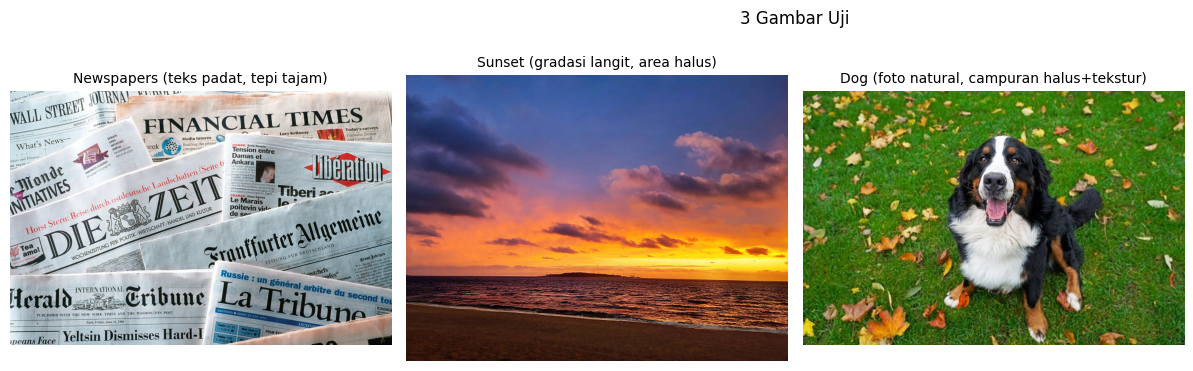

In [12]:
folder_gambar = 'images'

daftar_file = {
    'Newspapers (teks padat, tepi tajam)': 'newspapers.jpg',
    'Sunset (gradasi langit, area halus)': 'sunset.jpg',
    'Dog (foto natural, campuran halus+tekstur)': 'dog.jpeg',
}

koleksi_gambar = {}
for label, nama_file in daftar_file.items():
  path = os.path.join(folder_gambar, nama_file)
  bgr = cv2.imread(path)
  rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
  koleksi_gambar[label] = rgb
  print(f"{label:35s} -> ukuran {rgb.shape[1]}x{rgb.shape[0]}, total piksel {rgb.shape[0]*rgb.shape[1]}")

plt.figure(figsize=(16, 4))
for i, (label, im) in enumerate(koleksi_gambar.items()):
  plt.subplot(1, 4, i+1)
  plt.imshow(im)
  plt.title(label, fontsize=10)
  plt.axis('off')
plt.suptitle('3 Gambar Uji')
plt.tight_layout()
plt.show()

## 2. Down Sampling
Tiga metode downsampling berikut bekerja dengan prinsip yang sama, yaitu gaambar dipecah menjadi blok kecil berukuran (skala x skala) piksel, lalu tiap blok "diringkas" menjadi 1 piksel. Perbedaan terdapat dari cara meringkasnya:
* Max Pooling: mengambil nilai piksel paling tinggi (paling terang) di blok
* Average Pooling: mengambil mean --> mengambil nilai rata-rata seluruh piksel di blok
* Median Pooling: mengambil median --> mambil nilai tengah jika seluruh piksel di blok diurutkan


In [29]:
FACTOR = 6

def _crop_to_multiple(img, factor):
  h, w = img.shape[:2]
  h2, w2 = (h // factor) * factor, (w // factor) * factor
  return img[:h2, :w2]

def _to_blocks(channel, factor):
  h, w = channel.shape
  return channel.reshape(h // factor, factor, w // factor, factor).swapaxes(1, 2)

def downsampling_max(img, factor):
    img = _crop_to_multiple(img, factor)
    if img.ndim == 2:
        blocks = _to_blocks(img.astype(np.float64), factor)
        return blocks.max(axis=(2, 3)).astype(np.uint8)
    return np.stack([downsampling_max(img[:, :, k], factor) for k in range(img.shape[2])], axis=2)

def downsampling_rerata(img, factor):
    img = _crop_to_multiple(img, factor)
    if img.ndim == 2:
        blocks = _to_blocks(img.astype(np.float64), factor)
        return blocks.mean(axis=(2, 3)).astype(np.uint8)
    return np.stack([downsampling_rerata(img[:, :, k], factor) for k in range(img.shape[2])], axis=2)

def downsampling_median(img, factor):
    img = _crop_to_multiple(img, factor)
    if img.ndim == 2:
        blocks = _to_blocks(img.astype(np.float64), factor)
        return np.median(blocks, axis=(2, 3)).astype(np.uint8)
    return np.stack([downsampling_median(img[:, :, k], factor) for k in range(img.shape[2])], axis=2)

# def downsample(img, factor, method='max'):
#   """Manual block-based downsampling. method: 'max' | 'avg' | ' median'."""
#   img = _crop_to_multiple(img, factor)
#   if img.ndim == 2:
#     blocks = _to_blocks(img.astype(np.float64), factor)
#     if method == 'max':
#       out = blocks.max(axis=(2, 3))
#     elif method == 'avg':
#       out = blocks.mean(axis=(2, 3))
#     elif method == 'median':
#       out = np.median(blocks, axis=(2, 3))
#     else:
#       raise ValueError(method)
#     return np.clip(out, 0, 255).astype(np.uint8)
#   else:
#     return np.stack([downsample(img[:, :, c], factor, method) for c in range(img.shape[2])], axis=2)


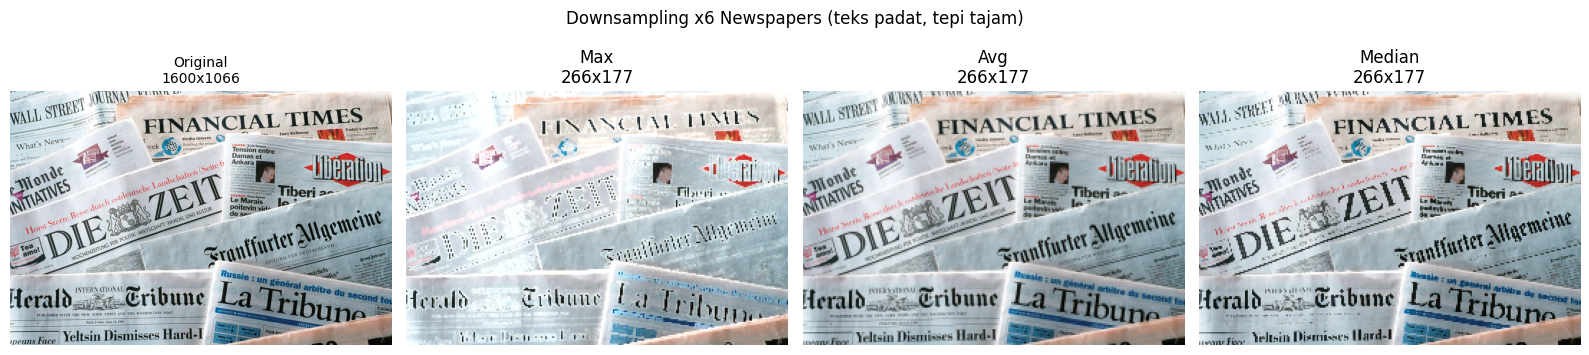

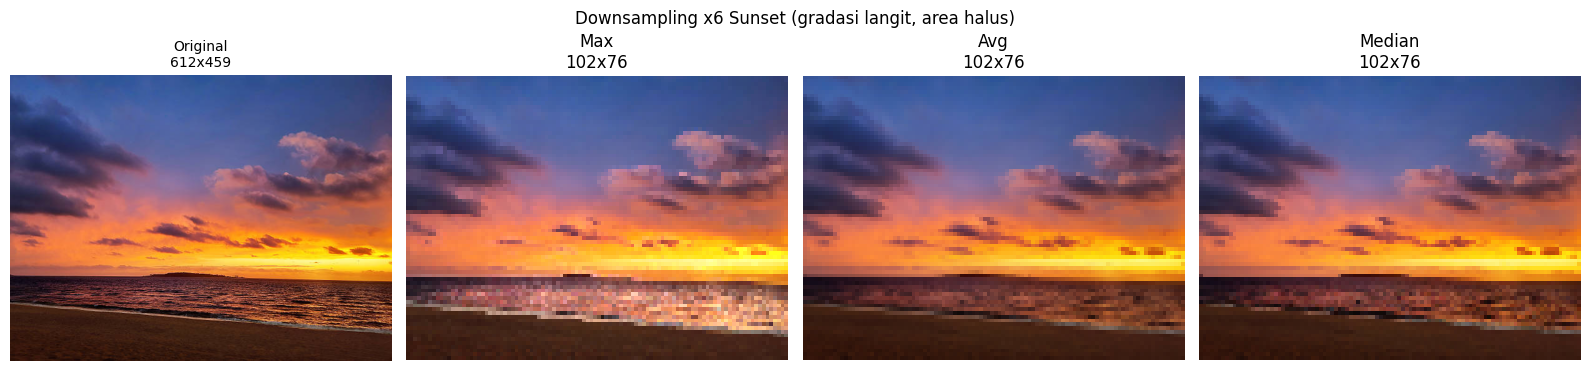

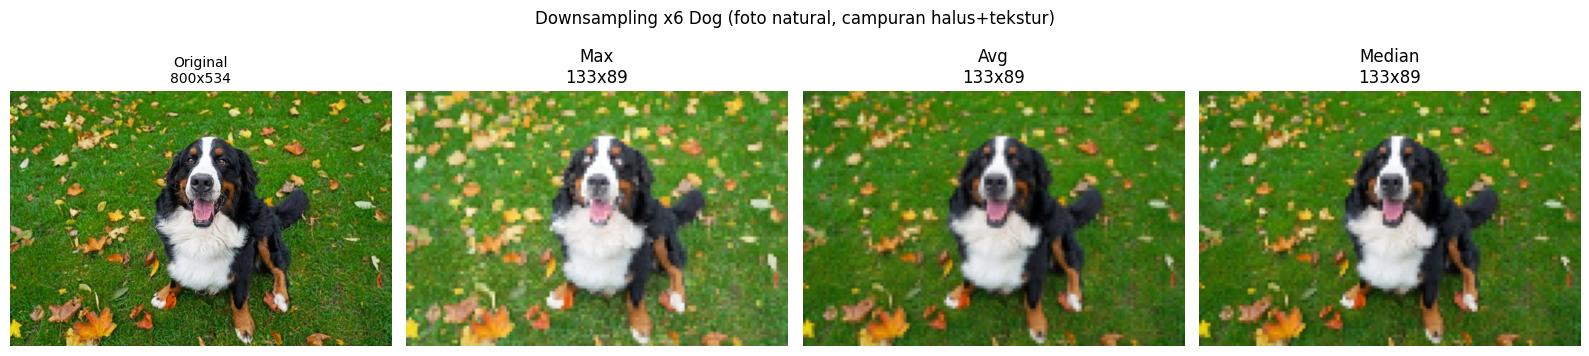

In [30]:
hasil_downsampling ={}

for label, im in koleksi_gambar.items():
  ds_max = downsampling_max(im, FACTOR)
  ds_rerata = downsampling_rerata(im, FACTOR)
  ds_median = downsampling_median(im, FACTOR)
  hasil_downsampling[label] = {'max': ds_max, 'avg': ds_rerata, 'median': ds_median}

  plt.figure(figsize=(16, 4))
  plt.subplot(1, 4, 1)
  plt.imshow(im)
  plt.title(f'Original\n{im.shape[1]}x{im.shape[0]}', fontsize=10)
  plt.axis('off')

  for i, (nama_metode, hasil) in enumerate([('Max', ds_max), ('Avg', ds_rerata), ('Median', ds_median)]):
    plt.subplot(1, 4, i+2)
    plt.imshow(hasil)
    plt.title(f'{nama_metode}\n{hasil.shape[1]}x{hasil.shape[0]}')
    plt.axis('off')
  plt.suptitle(f'Downsampling x{FACTOR} {label}')
  plt.tight_layout()
  plt.show()

## 3. Up Sampling
Tiga metode upsampling berikut digunakan untuk memperbesar kembali gambar yang sudah diperkecil (dari hasil downsampling average) ke ukuran semula, dengan cara "menebak" nilai piksel-piksel baru di antara piksel yang sudah ada:
* Nearest Neighbor: tiap piksel baru menyalin nilai piksel tetangga terdekatnya
* Bilinear: tiap piksel baru dihitung rata-rata berbobot 4 piksel tetangga terdekat
* Bicubic: tiap piksel baru dihitung dari 16 piksel tetangga (4x4) pakai kurva kubik, hasilnya paling smooth

Ketiganya diimplementasikan lewat cv2.resize dengan flag interpolasi yang sesuai.

In [31]:
def upsample(img, factor, method='nn'):
    h, w = img.shape[:2]
    new_size = (w * factor, h * factor)
    flag = {'nn': cv2.INTER_NEAREST, 'bilinear': cv2.INTER_LINEAR, 'bicubic': cv2.INTER_CUBIC}[method]
    return cv2.resize(img, new_size, interpolation=flag)

def compute_metrics(orig, recon):
    orig_c = orig[:recon.shape[0], :recon.shape[1]]
    p = psnr(orig_c, recon, data_range=255)
    s = ssim(orig_c, recon, channel_axis=2, data_range=255)
    return p, s

def upsampling_nn(im_small, target_height, target_width):
    return cv2.resize(im_small, (target_width, target_height), interpolation=cv2.INTER_NEAREST)

def upsampling_bilinear(im_small, target_height, target_width):
    return cv2.resize(im_small, (target_width, target_height), interpolation=cv2.INTER_LINEAR)

def upsampling_bicubic(im_small, target_height, target_width):
    return cv2.resize(im_small, (target_width, target_height), interpolation=cv2.INTER_CUBIC)

def compute_metrics(orig, reconst):
    """Hitung PSNR (dB) & SSIM antara gambar asli dan hasil rekonstruksi."""
    t, l = reconst.shape[:2]
    orig_c = orig[:t, :l]
    psnr_score = psnr(orig_c, reconst, data_range=255)
    ssim_score = ssim(orig_c, reconst, channel_axis=2, data_range=255)
    return psnr_score, ssim_score



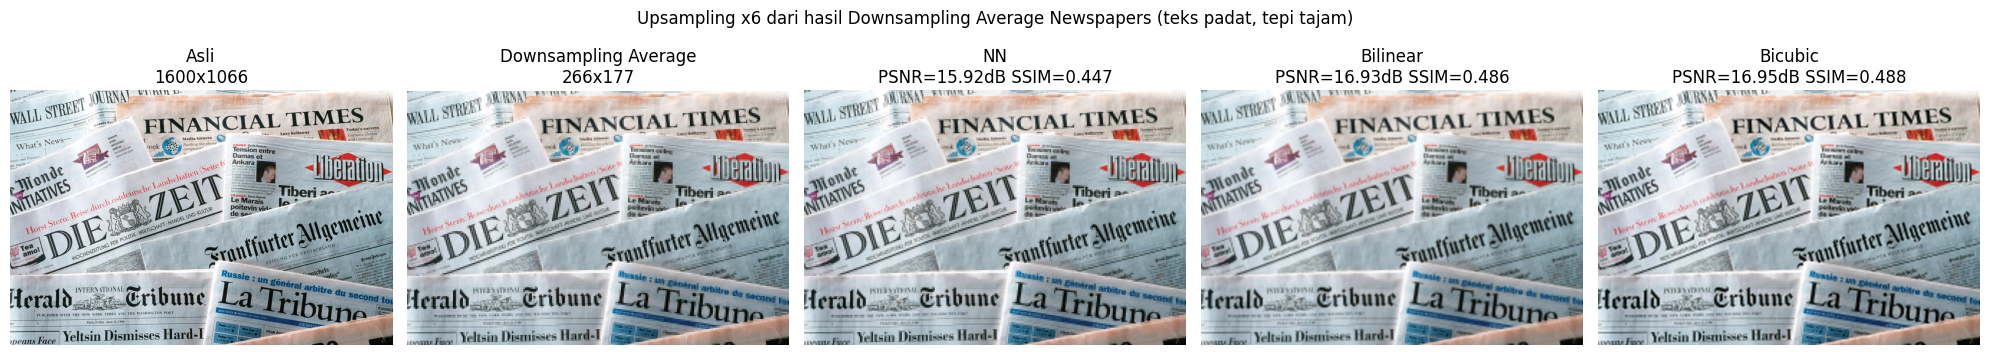

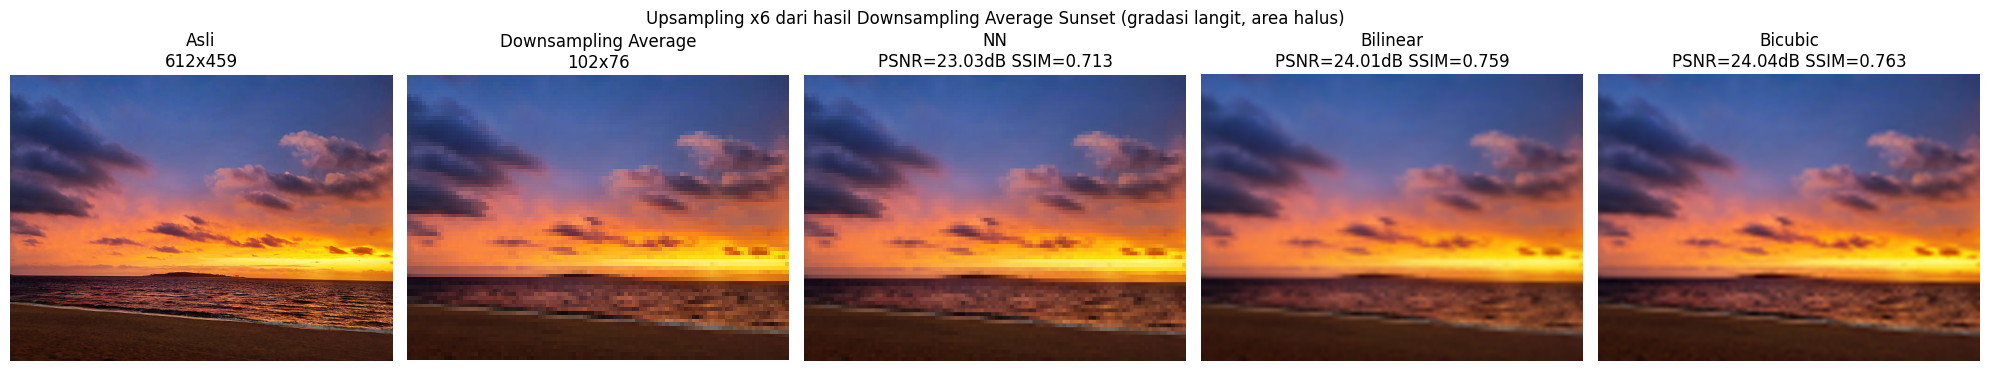

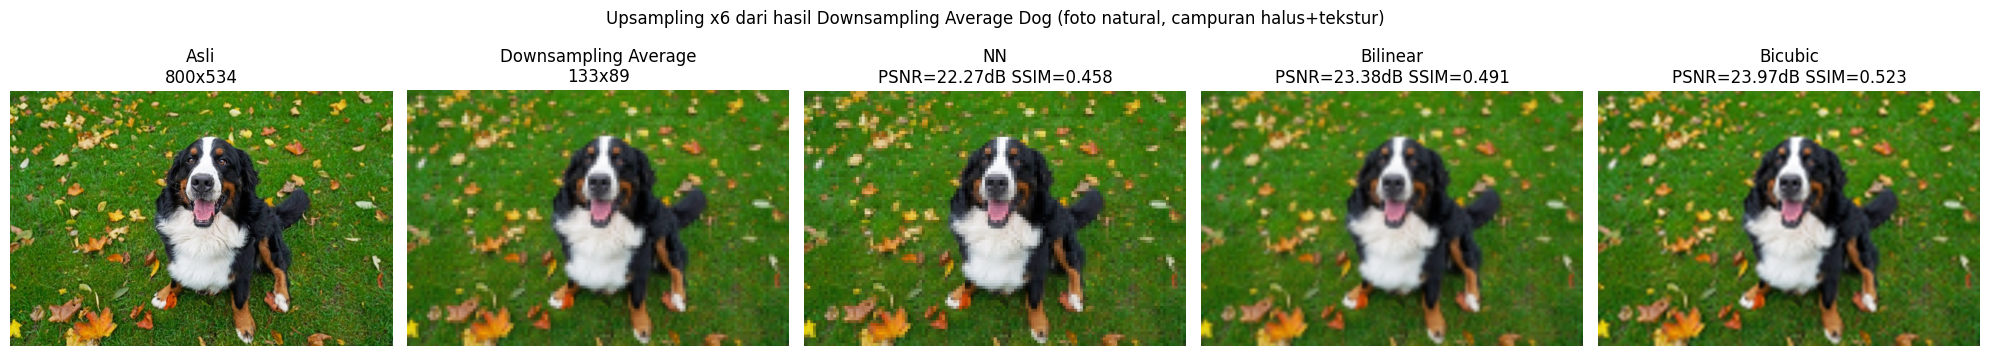

In [32]:
tabel_skor = []

for label, im in koleksi_gambar.items():
    im_small = hasil_downsampling[label]['avg']  # dari hasil downsampling rata-rata
    orig_height, orig_width = im.shape[0], im.shape[1]

    us_nn = upsampling_nn(im_small, orig_height, orig_width)
    us_bilinear = upsampling_bilinear(im_small, orig_height, orig_width)
    us_bicubic = upsampling_bicubic(im_small, orig_height, orig_width)

    plt.figure(figsize=(20, 4))
    plt.subplot(1, 5, 1)
    plt.imshow(im)
    plt.title(f'Asli\n{orig_width}x{orig_height}')
    plt.axis('off')

    plt.subplot(1, 5, 2)
    plt.imshow(im_small)
    plt.title(f'Downsampling Average\n{im_small.shape[1]}x{im_small.shape[0]}')
    plt.axis('off')

    for i, (nama_metode, hasil) in enumerate([('NN', us_nn), ('Bilinear', us_bilinear), ('Bicubic', us_bicubic)]):
        psnr_score, ssim_score = compute_metrics(im, hasil)
        tabel_skor.append((label, nama_metode, psnr_score, ssim_score))
        plt.subplot(1, 5, i + 3)
        plt.imshow(hasil)
        plt.title(f'{nama_metode}\nPSNR={psnr_score:.2f}dB SSIM={ssim_score:.3f}')
        plt.axis('off')

    plt.suptitle(f'Upsampling x{FACTOR} dari hasil Downsampling Average {label}')
    plt.tight_layout()
    plt.show()


## 3. Rekap Skor Kuantitatif
PSNR (satuan dB, makin tinggi makin mirip ke gambar asli) dan SSIM (0-1, makin mendekati 1 makin mirip secara struktural) dihitung untuk semua kombinasi gambar x metode upsampling.

In [33]:
import pandas as pd

df_skor = pd.DataFrame(tabel_skor, columns=['Gambar', 'Metode Upsampling', 'PSNR (dB)', 'SSIM'])
tabel_pivot = df_skor.pivot(index='Gambar', columns='Metode Upsampling', values='PSNR (dB)')
print("PSNR (dB) per gambar x metode upsampling:\n")
print(tabel_pivot.round(2))
df_skor


PSNR (dB) per gambar x metode upsampling:

Metode Upsampling                           Bicubic  Bilinear     NN
Gambar                                                              
Dog (foto natural, campuran halus+tekstur)    23.97     23.38  22.27
Newspapers (teks padat, tepi tajam)           16.95     16.93  15.92
Sunset (gradasi langit, area halus)           24.04     24.01  23.03


,Gambar,Metode Upsampling,PSNR (dB),SSIM
0,"Newspapers (teks padat, tepi tajam)",NN,15.917361,0.447026
1,"Newspapers (teks padat, tepi tajam)",Bilinear,16.934784,0.485627
2,"Newspapers (teks padat, tepi tajam)",Bicubic,16.945957,0.487955
3,"Sunset (gradasi langit, area halus)",NN,23.032200,0.712760
4,"Sunset (gradasi langit, area halus)",Bilinear,24.013766,0.758960
5,"Sunset (gradasi langit, area halus)",Bicubic,24.038958,0.763049
6,"Dog (foto natural, campuran halus+tekstur)",NN,22.274598,0.458150
7,"Dog (foto natural, campuran halus+tekstur)",Bilinear,23.384237,0.491107
8,"Dog (foto natural, campuran halus+tekstur)",Bicubic,23.968256,0.523232
